# XML and SVG
> Build XML element trees, serialize them and display SVG in notebooks

## Elements

In [ ]:
]help •element

`•element tag` returns an element function for XML tag `tag`. Call it with attributes on the left and children on the right, as in `["r":10] circle ""`. An empty right argument, `""` or `⍬`, gives no children. It returns a keyed vector with `tag`, `attrs` and `children` entries.

Errors: DOMAIN for invalid tag or attribute names.

Here `text` makes `text` elements. The result is an ordinary keyed vector:

In [ ]:
text←•element "text"
label←["x":10 "y":20] text "a < b"
label

["tag":"text" "attrs":["x":10 "y":20] "children":"a < b"]

## XML

In [ ]:
]help •xml

`•xml tree` returns the XML text of an element tree. It escapes `&`, `<`, `>` and `"` in text and attribute values. A numeric vector attribute becomes space-separated numbers. Children are text, elements or vectors of children. An element with no children closes itself.

Errors: DOMAIN for invalid names or attribute values.

`•xml` escapes text:

In [ ]:
•xml label

<text x="10" y="20">a &lt; b</text>

A numeric vector attribute becomes space-separated numbers. An element with no children closes itself. `""` and `⍬` both mean no children:

In [ ]:
g←•element "g"
•xml ["fill":"red" "points":[1 2 3 4]] g ⍬

<g fill="red" points="1 2 3 4"/>

Children can be a vector of elements:

In [ ]:
•xml g [text 'a';text 'b']

<g><text>a</text><text>b</text></g>

Attribute names keep their case. Prefixed names such as `xlink:href` pass through unchanged.

## SVG

In [ ]:
]help •svg

`X •svg children` returns an `svg` element with attributes `X`. It adds `xmlns` for the SVG namespace and `viewBox="0 0 100 100"`. Attributes in `X` replace these. Its `_mime_` field makes notebooks display it as a picture.

`width` and `height` set the picture's displayed size:

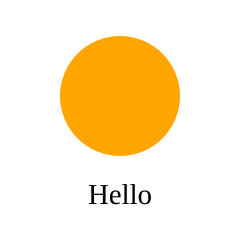

In [ ]:
circle←•element "circle"
c←["cx":50 "cy":40 "r":25 "fill":"orange"] circle ""
t←["x":50 "y":85 "text-anchor":"middle"] text "Hello"
pic←["width":240 "height":240] •svg [c t]
pic

Elements are keyed arrays with `tag`, `attrs` and `children` entries. Edit them using ordinary assignment. Display serializes the current tree.

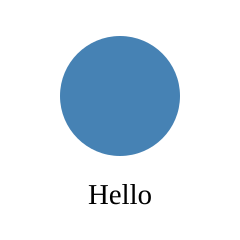

In [ ]:
pic.children.(0).attrs.fill←"steelblue"
pic

Override `viewBox` with four numbers to choose the drawing coordinates.

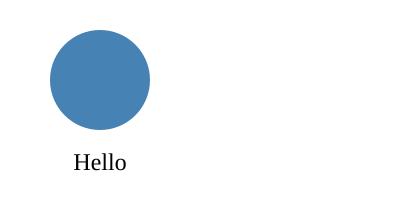

In [ ]:
["viewBox":[0 0 200 100] "width":400 "height":200] •svg pic.children

## Rich display

In [ ]:
]help •mime

`•mime Y` returns the MIME bundle that display uses for `Y`. The bundle is a keyed vector from MIME types to text. It always has `text/plain`. If `Y` has a function in its `_mime_` field, `•mime` calls it with `Y` as `⍵` and adds its entries.

Display shows the text form when a renderer fails. Only a direct `•mime` call reports the error.

Any keyed vector with a function in its `_mime_` field displays through that function. The function receives the keyed vector as `⍵` and returns a MIME-keyed array. Here the renderer displays the sum of `items`.

In [ ]:
total←["items":[1 2 3]]
total._mime_←{["text/plain":⍕+/⍵.items]}
total

6

`_mime_` is an ordinary field. Edits keep it. The renderer sees the current values.

In [ ]:
total.items+←10
total

36

`•mime` shows the bundle that display uses:

In [ ]:
•mime total

["text/plain":"36"]

Python arrays implement `_repr_mimebundle_()`. `apl(code, 'repl')` captures ordered events in `Result.events`. `Result.output` extracts their text. `⎕←` produces explicit text output. The native kernel, notebook magics and `bapl-nb --save` use the rich bundles.